In [1]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
class ChemicalSpecies(object):
    '''define the class of chemical species'''
    
    def __init__(self, name, count):
        self.name=name
        self.count=count
        

        
class Reaction(object):
    '''define the class of chemical reactions'''
    
    def __init__(self,reactant_list, product_list, coefficient_dic, reconstant):
        self.reactant_list=reactant_list
        self.product_list=product_list
        self.coefficient_dic=coefficient_dic
        self.reaction_constant=reconstant
        
        
    def get_propensity(self):
        '''calculate the propensity of the chemical reaction'''
        k=1
        for i in self.reactant_list:
            k=k*i.count**self.coefficient_dic[i.name]
            
        propensity=self.reaction_constant*k
        return propensity
          
        
    def execute(self):
        '''calculate the molecular count of reactants and products after the reaction has been executed'''
        for i in self.reactant_list:
            i.count-=self.coefficient_dic[i.name]
            
        for j in self.product_list:
            j.count+=self.coefficient_dic[j.name]
            
        return self.reactant_list,self.product_list
    
    
    
class System(object):
    '''define the class of chemical system'''
    
    def __init__(self, reaction_list,start_time=0):
        self.reaction_list=reaction_list
        self.start_time=start_time
    
    
    def run_directmethod(self):
        '''Use the Direct Method to simulate one reaction step of the system with 5 reactions in Gibson et al'''
    
        rx1,rx2,rx3,rx4,rx5=self.reaction_list   # use rx1~rx5 to store the 5 chemical reactions
        
        # use h,s,j,k,l,m,n to store the 7 chemical species involved in the 5 chemical reactions
        # (since i has been used, use s to replace i.)
        # the initial value of them would be got from the self.chemical_list, then after each round
        # of run_directmethod, they would be updated by the results of run_directmethod (will store
        # in chemicals)
        
        chemicalpre_list=[]    
        
        for i in self.reaction_list:
            for j in i.reactant_list:
                chemicalpre_list.append(j)
    
        chemical_set=set(chemicalpre_list)
                    
        chemical_list=list(chemical_set)
        
        chemical_list.sort(key=lambda x: x.name)
        
            
        h,s,j,k,l,m,n=chemical_list   # when run_directmethod has been run, update the value of h~n

        in_equilibrium = False   # a marker to determine whether the system has reached equilibrium
        prop1=rx1.get_propensity()
        prop2=rx2.get_propensity()
        prop3=rx3.get_propensity()
        prop4=rx4.get_propensity()
        prop5=rx5.get_propensity()
        
        propensity_list=[prop1,prop2,prop3,prop4,prop5]
        
        sumprop=sum(propensity_list)
        
        prob_list=[]
        if sumprop>0:                                     
            for i in propensity_list:                    
                prob_list.append(i/sumprop)  
        elif sumprop==0:                                            
            in_equilibrium = True
        else:
            print("Error: negative propensities.")
           
        tau=0               # the initial value of tau would be 0. If sum(prob_list)!=0, then update tau. If sum(prop_list)==0
                            # If sum(prop_list)==0, which means the system has reached equilibrium, do not update tau and just
                            # return tau as 0.
            
        if sum(prob_list)!=0:                             # update h~n using Directmethod.    
            u=random.choice(np.arange(0,5),p=prob_list)   
            tau=random.exponential(1/sumprop)
        
            if u==0:
                [h,s],[j]=rx1.execute()
            elif u==1:
                [s,j],[k]=rx2.execute()
            elif u==2:
                [k,l],[l,m]=rx3.execute()
            elif u==3:
                [m],[k,n]=rx4.execute()
            else:
                [l,n],[h]=rx5.execute()
        
        
        species_list=[h,s,j,k,l,m,n]   
        
        return species_list, tau, in_equilibrium

        
        
    def simulate(self,end_time):
        '''Stimulate the reactions during a given time period from start_time to end_time'''
        
        t0=0
        t_list=[]
        chemcount_list=[] 
        totalcount_list=[] 
        
        equilibrium=False
  
        chem_list=[]
    
       
        while t0<end_time:   
            species_list, t, equilibrium=self.run_directmethod() 
                                                                         
            if t!=0:  
                t0+=t  
                t_list.append(t0)
                chem_list.append(species_list) 
                    
                chemcount_list=[]   # after each round of run_directmethod, store the updated molecular count of chemical
                for i in species_list:   # species into chemcount_list
                    chemcount_list.append(i.count)
                totalcount_list.append(chemcount_list)      # store the chemcount_list into totalcount_list

            else: # t=0 means sum(prob_list)==0, the system has reached equilibrium
                equilibrium=True
                break
            
        return np.array(t_list), np.array(totalcount_list), equilibrium
    
    
    
    def display(self, end_time, time):
        '''get the system state (molecular count of each chemical) at a given time point'''
        
        td,c,s=self.simulate(end_time) # run the stimulate method and store the results in td, c and s
        
        if time<td[-1]:#if the given time is smaller then td[-1](the equilibrium time), it means the system has not reached 
            n=len(td)   # equilirium
            for i in range(n): # from the first element in td to search the elements which time is between them.
                if time>=td[i] and time<td[i+1]: # then get the corresponding element in c, this system state at given time
                    system_state=c[i]            # has the same molecular counts with this element
                    break
                   
        else:  # if the given time is larger than td[-1](the equilibrium time), it means the system has reached equilirium
            system_state=c[-1]  # just give the last element in c (the equilibrium state) to system_state

        print(list(zip(td,c)))
        print("The system state at time: {0} is: {1}".format(time,system_state))
        plt.plot(td,c)
     

[(0.0015422600969991858, array([ 6, 14,  8, 13,  9,  2,  6])), (0.0035043931293338277, array([ 6, 13,  7, 14,  9,  2,  6])), (0.0049310826967596333, array([ 7, 13,  7, 14,  8,  2,  5])), (0.0051779493992732241, array([ 7, 12,  6, 15,  8,  2,  5])), (0.0053071420454546565, array([ 7, 12,  6, 14,  8,  3,  5])), (0.0055480240442857039, array([ 7, 12,  6, 13,  8,  4,  5])), (0.0057081512502168349, array([ 6, 11,  7, 13,  8,  4,  5])), (0.0080469047831794403, array([ 5, 10,  8, 13,  8,  4,  5])), (0.0090882778340780485, array([ 6, 10,  8, 13,  7,  4,  4])), (0.0092438484390809528, array([ 5,  9,  9, 13,  7,  4,  4])), (0.0097957422778344478, array([ 5,  9,  9, 12,  7,  5,  4])), (0.011502297279464125, array([ 5,  9,  9, 11,  7,  6,  4])), (0.011740147303066663, array([ 5,  8,  8, 12,  7,  6,  4])), (0.015395711725181258, array([ 6,  8,  8, 12,  6,  6,  3])), (0.015978874293612926, array([ 5,  7,  9, 12,  6,  6,  3])), (0.020587099115796207, array([ 5,  7,  9, 13,  6,  5,  4])), (0.020634845

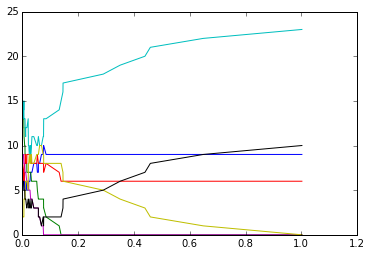

In [16]:
a=ChemicalSpecies('A',6)
b=ChemicalSpecies('B',14)
c=ChemicalSpecies('C',8)
d=ChemicalSpecies('D',12)
e=ChemicalSpecies('E',9)
f=ChemicalSpecies('F',3)
g=ChemicalSpecies('G',5)

chemical_list=[a,b,c,d,e,f,g]

rx1=Reaction([a, b],[c],{a.name:1,b.name:1,c.name:1},1)
rx2=Reaction([b, c],[d],{b.name:1,c.name:1,d.name:1},2)
rx3=Reaction([d,e],[e,f],{d.name:1,e.name:1,e.name:1,f.name:1},3)
rx4=Reaction([f],[d,g],{f.name:1,d.name:1,g.name:1},4)
rx5=Reaction([e, g],[a],{e.name:1,g.name:1,a.name:1},5)

reaction_list=[rx1,rx2,rx3,rx4,rx5]


system= System(reaction_list)
# s=system.run_directmethod()
# print(s)


# w=system.simulate(5)
# print(w)

v=system.display(5,0.7)
print(v)
